In [1]:
## Import Modules

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [3]:
## Import Dataset

In [4]:
titanic = sns.load_dataset("titanic")

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [9]:
#Fill Missing Values

imp_median= SimpleImputer(strategy="median")
titanic[["age"]] =imp_median.fit_transform(titanic[["age"]])

imp_freq= SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]  =imp_freq.fit_transform(titanic[["embarked"]])


In [10]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
## Encoding

le= LabelEncoder()

titanic["sex"]= le.fit_transform(titanic["sex"])
titanic["embarked"]= le.fit_transform(titanic["embarked"])

In [12]:
X= titanic[features]
y=titanic[target]

In [13]:
## Train Test Split

In [14]:
X_train, X_test, y_train, y_test= train_test_split(X, y , test_size=0.2, random_state=42)

In [15]:
## Decision Tree Model

In [16]:
model= DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred= model.predict(X_test)

print(f"Accuracy Score Is:{accuracy_score(y_test,y_pred)}")

Accuracy Score Is:0.7597765363128491


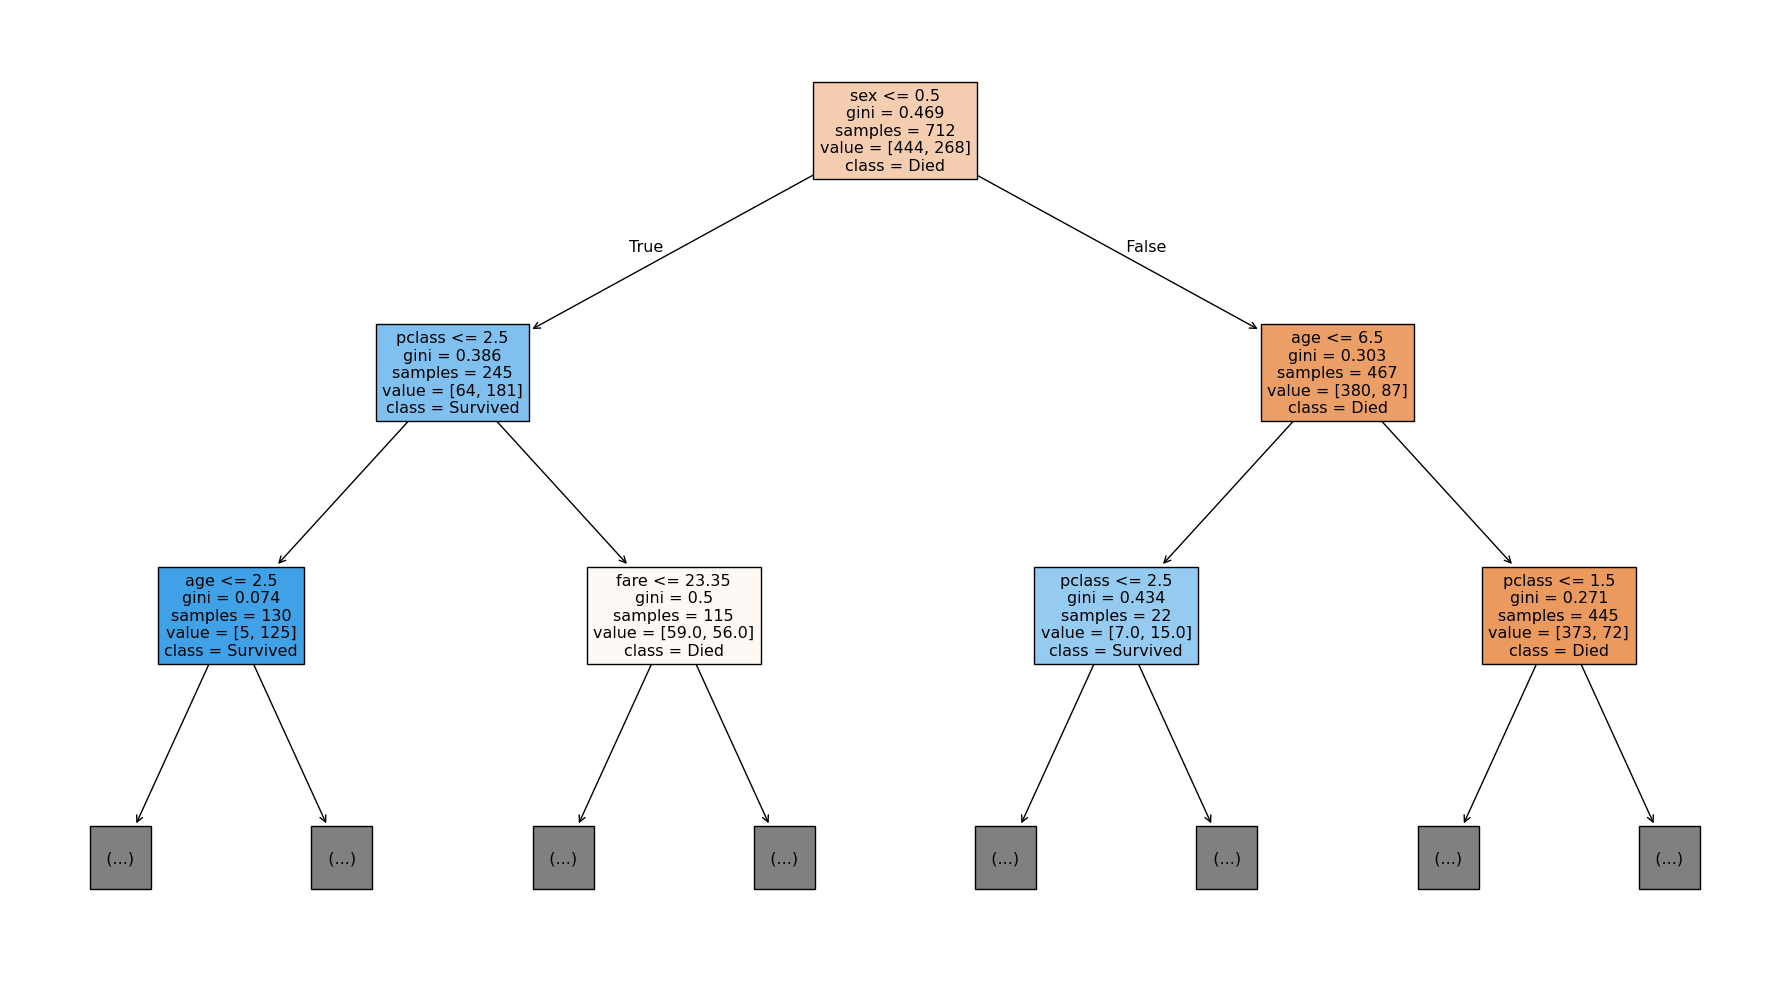

In [18]:
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()


In [19]:
## Decision Tree With Pre Pruning

In [20]:
max_depths=[22,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model= DecisionTreeClassifier()
    model.fit(X_train, y_train)

    y_pred= model.predict(X_test)
    acc=model.score(X_test, y_test)
    print(f"For Depth= {depth}, Accuracy = {acc}")

    

For Depth= 22, Accuracy = 0.776536312849162
For Depth= 3, Accuracy = 0.776536312849162
For Depth= 4, Accuracy = 0.776536312849162
For Depth= 5, Accuracy = 0.7597765363128491
For Depth= 6, Accuracy = 0.770949720670391
For Depth= 7, Accuracy = 0.7597765363128491
For Depth= 8, Accuracy = 0.7597765363128491
For Depth= 9, Accuracy = 0.776536312849162
For Depth= 10, Accuracy = 0.7821229050279329


In [21]:
min_samples_splits=[10,15,20,25,30]

for split in min_samples_splits:
    model= DecisionTreeClassifier(max_depth=7, min_samples_split=split)
    model.fit(X_train, y_train)

    acc=model.score(X_test, y_test)
    print(f"For Sample Split= {split}, Accuracy = {acc}")
    
    

For Sample Split= 10, Accuracy = 0.8268156424581006
For Sample Split= 15, Accuracy = 0.8268156424581006
For Sample Split= 20, Accuracy = 0.8268156424581006
For Sample Split= 25, Accuracy = 0.8100558659217877
For Sample Split= 30, Accuracy = 0.7988826815642458


In [22]:
## Decision Tree With Post Pruning

In [23]:
full_tree = DecisionTreeClassifier(random_state=42)

full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
path =full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [25]:
## Train Our Model For All Alphas

In [26]:
# Train Our Model For All Alphas
tree= []

for alpha in ccp_alphas:
    model= DecisionTreeClassifier(random_state=42, ccp_alpha= alpha)
    model.fit(X_train, y_train)
    model.score(X_test, y_test)

    tree.append((model, alpha))

In [27]:
best_acc=0
best_alpha=0

for model, alpha in tree:
    curr_acc= model.score(X_test, y_test)
    if curr_acc> best_acc:
        best_acc=curr_acc
        best_alpha= alpha
    

In [28]:
best_alpha

np.float64(0.0015407231242023183)

In [29]:
best_acc

0.8379888268156425

In [30]:
best_model = DecisionTreeClassifier(ccp_alpha= best_alpha)
best_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


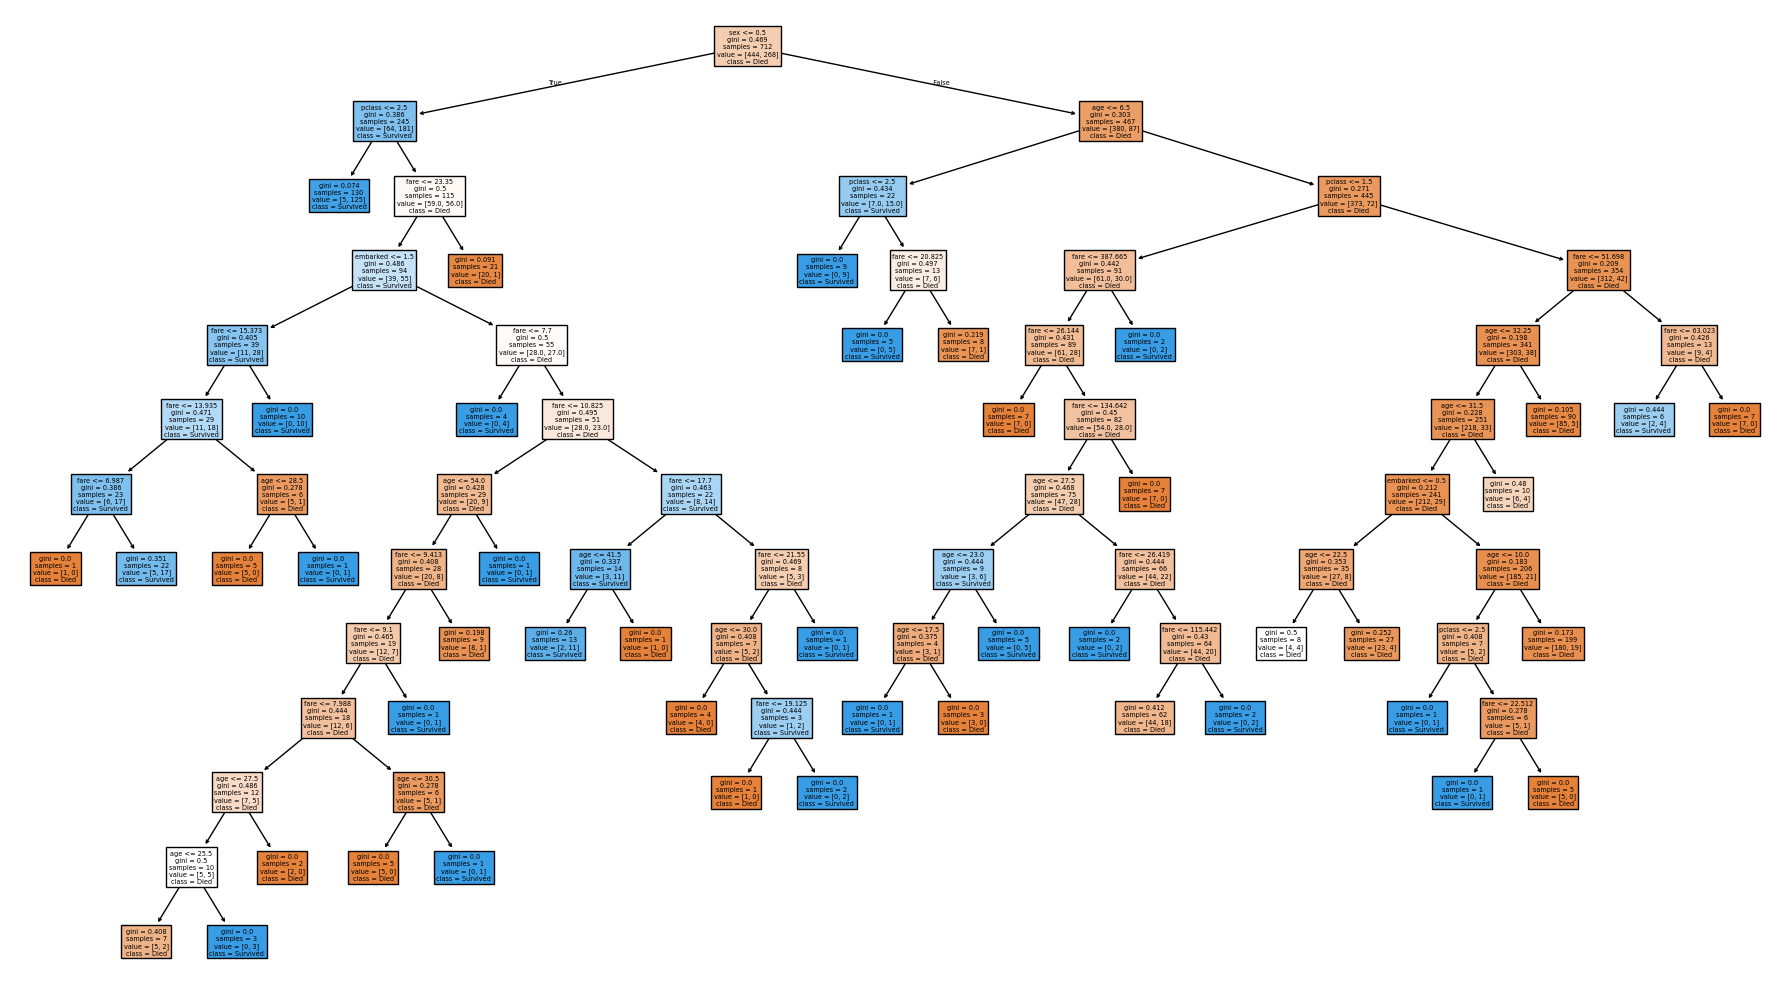

In [31]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
    
)
plt.tight_layout()
plt.show()

In [33]:
titanic.to_csv("exmple.csv")